In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


To Read the CSV File

In [ ]:
df=pd.read_csv("/content/Diwali Sales Data 1.csv",encoding= 'unicode_escape')
df


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0000
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0000
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0000
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0000
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11238,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,-386492.5497
11239,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,-386529.0914
11240,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,-386565.6332
11241,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,-386602.1750


In [ ]:
df.describe()



,User_ID,Age,Marital_Status,Orders,Amount
count,1.124300e+04,11243.000000,11243.000000,11243.000000,11240.000000
mean,1.003005e+06,35.422841,0.420261,2.488749,-181292.080325
std,1.716141e+03,12.756369,0.493623,1.114960,118572.893099
min,1.000001e+06,12.000000,0.000000,1.000000,-386638.716800
25%,1.001494e+06,27.000000,0.000000,1.000000,-283965.453850
50%,1.003065e+06,33.000000,0.000000,2.000000,-181292.190850
75%,1.004430e+06,43.000000,1.000000,3.000000,-78618.927895
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [ ]:

# Select only numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
print(f"Cleaned dataset shape: {df.shape}")


Cleaned dataset shape: (10957, 13)


In [ ]:
df.to_csv("/content/Diwali_Sales_Cleaned.csv", index=False)
df


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0000
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0000
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0000
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0000
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11238,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,-386492.5497
11239,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,-386529.0914
11240,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,-386565.6332
11241,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,-386602.1750


/tmp/ipython-input-10237788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Amount', data=gender_purchase, palette='coolwarm')


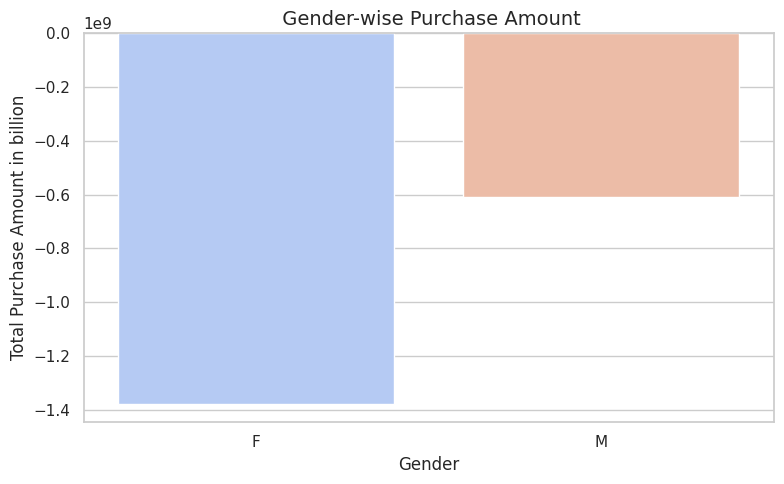

In [ ]:

# Group by Gender and sum Amount
gender_purchase = df.groupby('Gender')['Amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Gender', y='Amount', data=gender_purchase, palette='coolwarm')
plt.title(' Gender-wise Purchase Amount', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount in billion')
plt.tight_layout()
plt.show()


/tmp/ipython-input-3291359451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age Group', y='Amount', data=agegroup_purchase, palette='viridis')


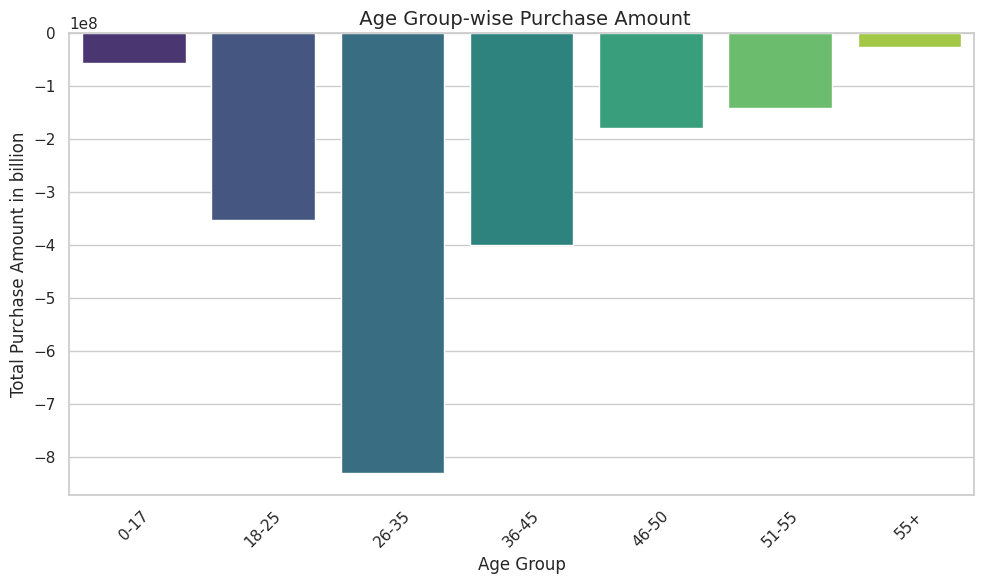

In [ ]:

# Group by Age Group and sum Amount
agegroup_purchase = df.groupby('Age Group')['Amount'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Age Group', y='Amount', data=agegroup_purchase, palette='viridis')

plt.title(' Age Group-wise Purchase Amount', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount in billion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-134301144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Amount', data=state_sales, palette='mako')


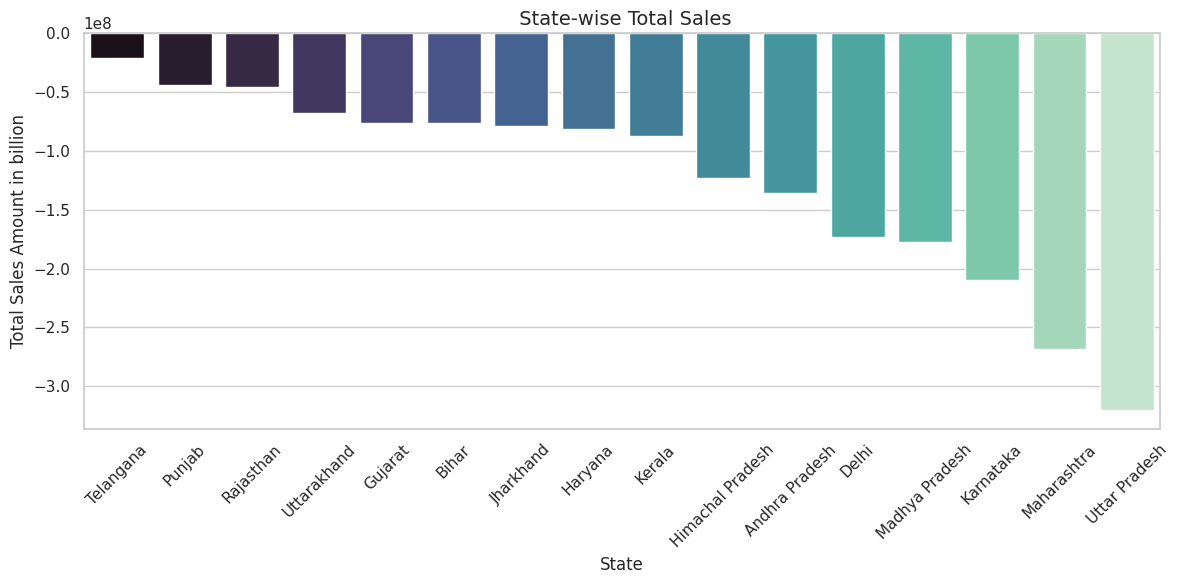

In [ ]:
state_sales = df.groupby('State')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='State', y='Amount', data=state_sales, palette='mako')
plt.title(' State-wise Total Sales', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Sales Amount in billion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-508580647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Amount', data=occupation_purchase, palette='cubehelix')


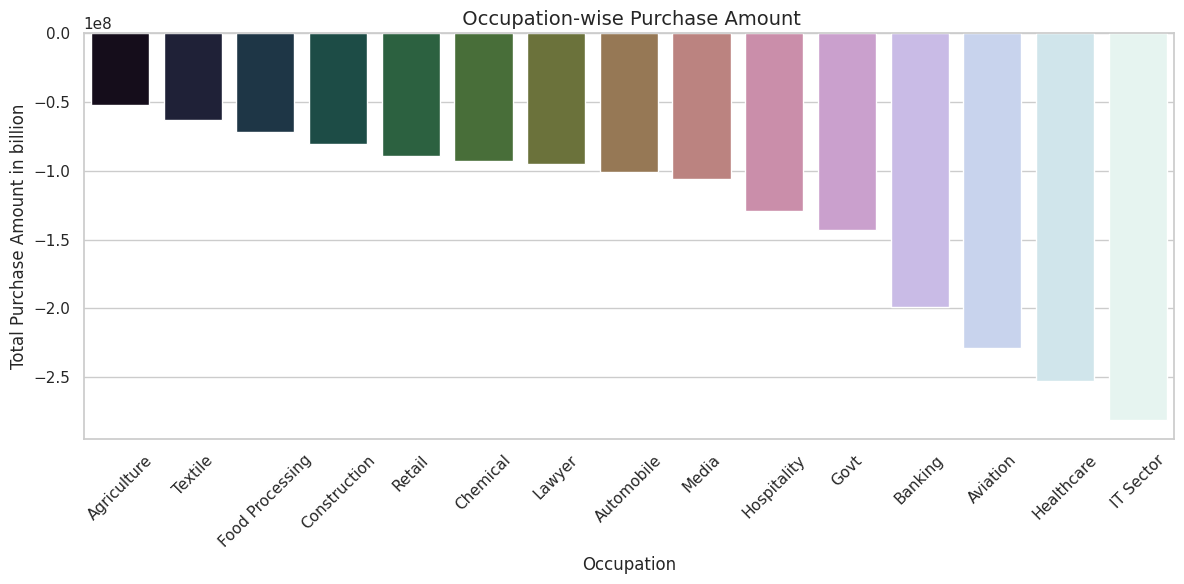

In [ ]:
# Group by Occupation and sum Amount
occupation_purchase = df.groupby('Occupation')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Occupation', y='Amount', data=occupation_purchase, palette='cubehelix')
plt.title(' Occupation-wise Purchase Amount', fontsize=14)
plt.xlabel('Occupation')
plt.ylabel('Total Purchase Amount in billion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3891252899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Orders', data=category_popularity, palette='coolwarm')
/tmp/ipython-input-3891252899.py:13: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


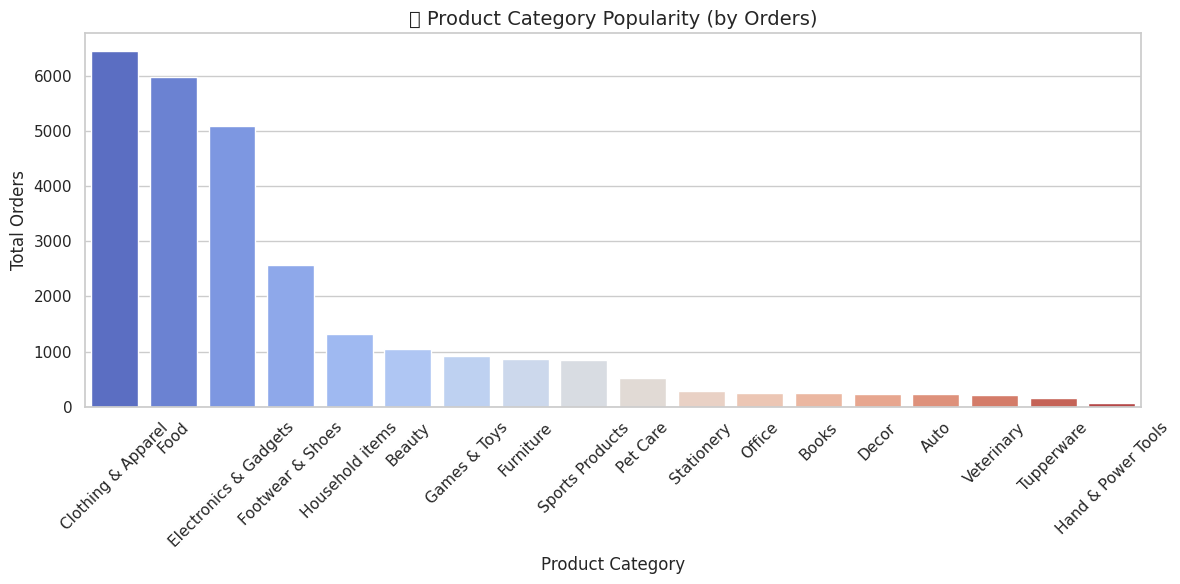

In [ ]:
# Group by Product Category and count Orders
category_popularity = df.groupby('Product_Category')['Orders'].sum().reset_index().sort_values(by='Orders', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Product_Category', y='Orders', data=category_popularity, palette='coolwarm')
plt.title('Product Category Popularity (by Orders)', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1878753245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Marital_Status', y='Amount', data=marital_sales, palette='Set1')


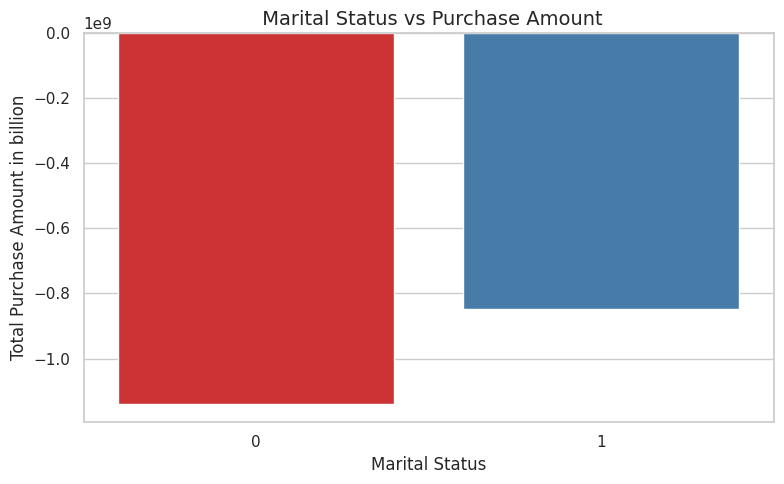

In [ ]:
# Group by Marital Status and sum Amount
marital_sales = df.groupby('Marital_Status')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Marital_Status', y='Amount', data=marital_sales, palette='Set1')
plt.title(' Marital Status vs Purchase Amount', fontsize=14)
plt.xlabel('Marital Status')
plt.ylabel('Total Purchase Amount in billion')
plt.tight_layout()
plt.show()


/tmp/ipython-input-557128846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Amount', data=top_states, palette='plasma')


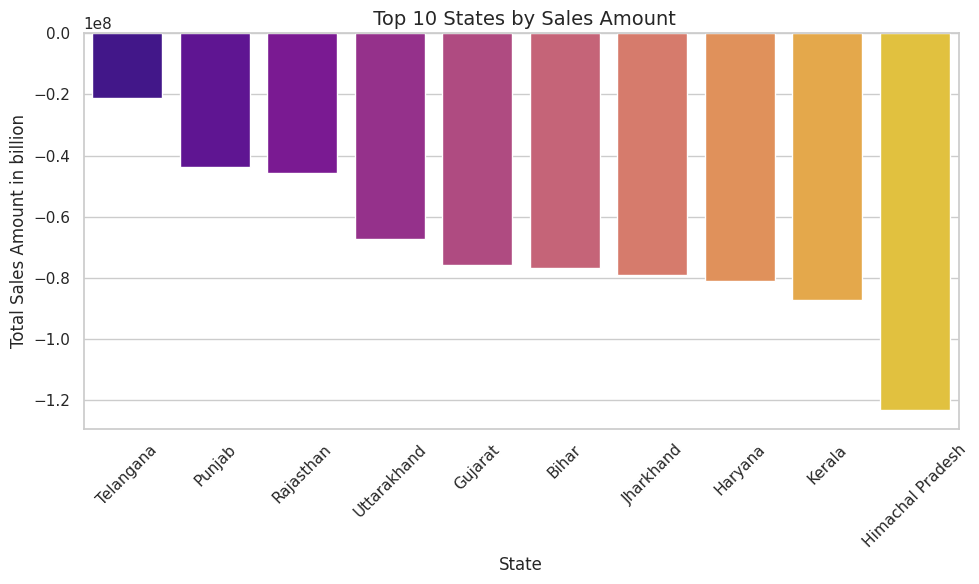

In [ ]:
# Group by State and sum Amount
state_sales = df.groupby('State')['Amount'].sum().reset_index()
top_states = state_sales.sort_values(by='Amount', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='State', y='Amount', data=top_states, palette='plasma')
plt.title(' Top 10 States by Sales Amount', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Sales Amount in billion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1939165418.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


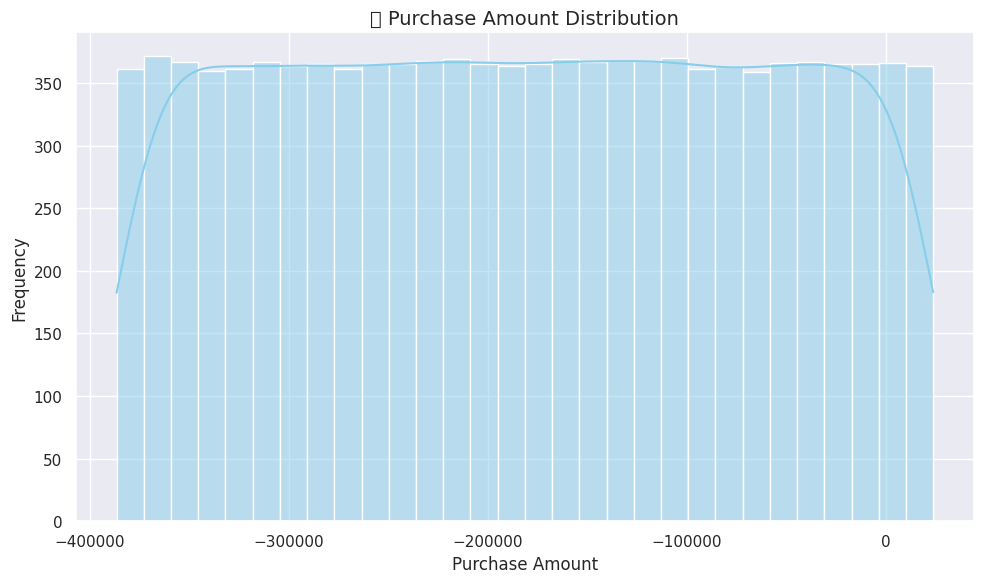

In [ ]:

sns.set(style="darkgrid")

plt.figure(figsize=(10,6))
sns.histplot(df['Amount'], bins=30, kde=True, color='skyblue')
plt.title('📈 Purchase Amount Distribution', fontsize=14)
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


/tmp/ipython-input-3999508255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Amount', data=df, palette='Set3')
/tmp/ipython-input-3999508255.py:12: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129485 (\N{STANDING PERSON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


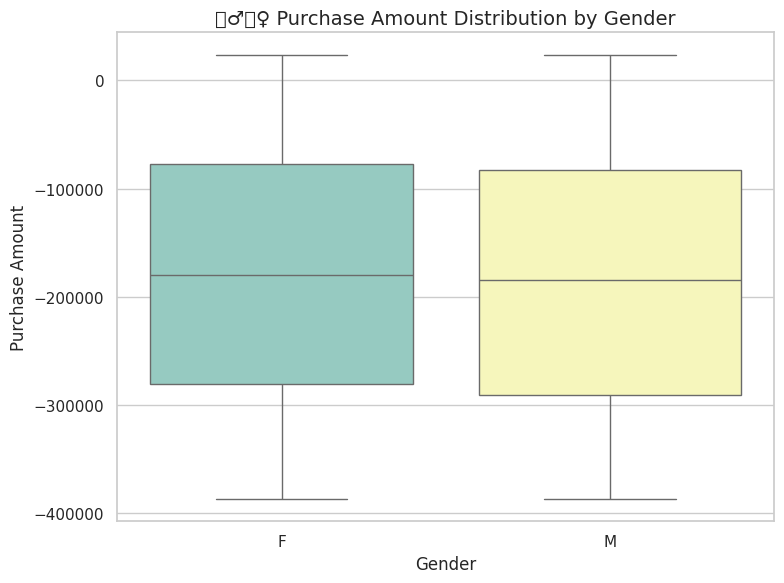

In [ ]:

sns.set(style="whitegrid")

# Plot boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Amount', data=df, palette='Set3')
plt.title(' Purchase Amount Distribution by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.tight_layout()
plt.show()
